In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('Housing_Data.csv')

In [3]:
!ls

01_Data_Preparation.ipynb  Ames_Housing_Feature_Description.txt
04_Data_Cleaning	   Housing_Data.csv


In [4]:
with open('Ames_Housing_Feature_Description.txt', 'r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

# EDA

In [5]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [7]:
#corr
df.corr()['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

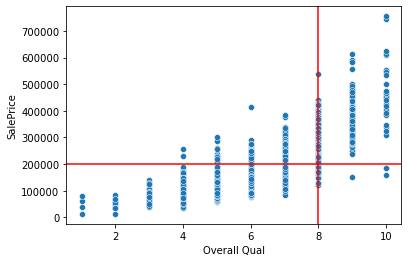

In [8]:
sns.scatterplot(data=df, x='Overall Qual', y='SalePrice')
plt.axhline(y=200000, color='r')
plt.axvline(x=8, color='r')

In [9]:
df[(df['Overall Qual']>8)&(df['SalePrice']<200000)][['Overall Qual', 'SalePrice']]

,Overall Qual,SalePrice
1182,9,150000
1498,10,160000
2180,10,183850
2181,10,184750


In [10]:
index_drop  = df[(df['Overall Qual']>8)&(df['SalePrice']<200000)].index

In [11]:
index_drop

Int64Index([1182, 1498, 2180, 2181], dtype='int64')

In [12]:
df = df.drop(index_drop, axis=0)

<AxesSubplot:xlabel='Overall Qual', ylabel='SalePrice'>

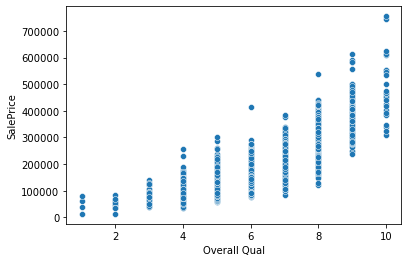

In [13]:
sns.scatterplot(data=df, x='Overall Qual', y='SalePrice')

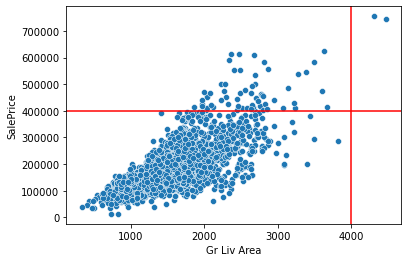

In [14]:
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice')
plt.axhline(y=400000, color='r')
plt.axvline(x=4000, color='r')

In [15]:
df[(df['Gr Liv Area']>4000)&(df['SalePrice']>400000)][['Gr Liv Area', 'SalePrice']]

,Gr Liv Area,SalePrice
1760,4476,745000
1767,4316,755000


In [16]:
index_drop  = df[(df['Gr Liv Area']>4000)&(df['SalePrice']>400000)].index

In [17]:
index_drop

Int64Index([1760, 1767], dtype='int64')

In [18]:
df = df.drop(index_drop, axis=0)

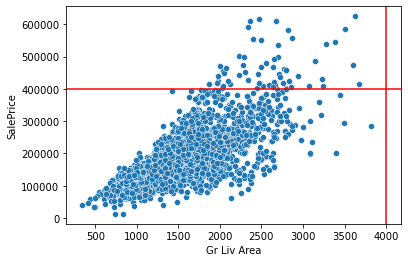

In [19]:
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice')
plt.axhline(y=400000, color='r')
plt.axvline(x=4000, color='r')

In [20]:
df.corr()['SalePrice'].sort_values()

PID               -0.246358
Enclosed Porch    -0.129357
Kitchen AbvGr     -0.120969
Overall Cond      -0.103699
MS SubClass       -0.086900
Bsmt Half Bath    -0.045780
Low Qual Fin SF   -0.037851
Yr Sold           -0.028091
Misc Val          -0.019196
BsmtFin SF 2       0.007399
3Ssn Porch         0.033292
Pool Area          0.035485
Mo Sold            0.039831
Screen Porch       0.115523
Bedroom AbvGr      0.139793
Bsmt Unf SF        0.185187
2nd Flr SF         0.257702
Lot Area           0.270460
Bsmt Full Bath     0.281160
Half Bath          0.285402
Open Porch SF      0.322135
Wood Deck SF       0.326976
Lot Frontage       0.360431
BsmtFin SF 1       0.444485
Fireplaces         0.475005
TotRms AbvGrd      0.498940
Mas Vnr Area       0.516541
Garage Yr Blt      0.534005
Year Remod/Add     0.540269
Full Bath          0.544662
Year Built         0.565153
1st Flr SF         0.643227
Garage Area        0.648955
Garage Cars        0.653073
Total Bsmt SF      0.658651
Gr Liv Area        0

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2924 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2924 non-null   int64  
 1   MS SubClass      2924 non-null   int64  
 2   MS Zoning        2924 non-null   object 
 3   Lot Frontage     2435 non-null   float64
 4   Lot Area         2924 non-null   int64  
 5   Street           2924 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2924 non-null   object 
 8   Land Contour     2924 non-null   object 
 9   Utilities        2924 non-null   object 
 10  Lot Config       2924 non-null   object 
 11  Land Slope       2924 non-null   object 
 12  Neighborhood     2924 non-null   object 
 13  Condition 1      2924 non-null   object 
 14  Condition 2      2924 non-null   object 
 15  Bldg Type        2924 non-null   object 
 16  House Style      2924 non-null   object 
 17  Overall Qual  

In [22]:
#removing unuseless columns
df = df.drop('PID', axis=1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2924 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2924 non-null   int64  
 1   MS Zoning        2924 non-null   object 
 2   Lot Frontage     2435 non-null   float64
 3   Lot Area         2924 non-null   int64  
 4   Street           2924 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot Shape        2924 non-null   object 
 7   Land Contour     2924 non-null   object 
 8   Utilities        2924 non-null   object 
 9   Lot Config       2924 non-null   object 
 10  Land Slope       2924 non-null   object 
 11  Neighborhood     2924 non-null   object 
 12  Condition 1      2924 non-null   object 
 13  Condition 2      2924 non-null   object 
 14  Bldg Type        2924 non-null   object 
 15  House Style      2924 non-null   object 
 16  Overall Qual     2924 non-null   int64  
 17  Overall Cond  

In [24]:
df.isnull()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2926,False,False,True,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
2927,False,False,False,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2928,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [25]:
df.isnull().sum()

MS SubClass         0
MS Zoning           0
Lot Frontage      489
Lot Area            0
Street              0
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 80, dtype: int64

In [26]:
100*(df.isnull().sum()/len(df))

MS SubClass        0.000000
MS Zoning          0.000000
Lot Frontage      16.723666
Lot Area           0.000000
Street             0.000000
                    ...    
Mo Sold            0.000000
Yr Sold            0.000000
Sale Type          0.000000
Sale Condition     0.000000
SalePrice          0.000000
Length: 80, dtype: float64

In [27]:
def missing_precent(dataframe):
    nan_percent = 100*(dataframe.isnull().sum()/len(dataframe))
    nan_percent = nan_percent[nan_percent>0].sort_values()
    return nan_percent

In [28]:
nan_percent = missing_precent(df)

In [29]:
nan_percent

Electrical         0.034200
Garage Area        0.034200
Total Bsmt SF      0.034200
Bsmt Unf SF        0.034200
BsmtFin SF 1       0.034200
BsmtFin SF 2       0.034200
Garage Cars        0.034200
Bsmt Full Bath     0.068399
Bsmt Half Bath     0.068399
Mas Vnr Area       0.786594
Mas Vnr Type       0.786594
BsmtFin Type 1     2.735978
Bsmt Qual          2.735978
Bsmt Cond          2.735978
BsmtFin Type 2     2.770178
Bsmt Exposure      2.838577
Garage Type        5.369357
Garage Finish      5.437756
Garage Qual        5.437756
Garage Cond        5.437756
Garage Yr Blt      5.437756
Lot Frontage      16.723666
Fireplace Qu      48.632011
Fence             80.471956
Alley             93.228454
Misc Feature      96.409029
Pool QC           99.623803
dtype: float64

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26]),
 [Text(0, 0, 'Electrical'),
  Text(1, 0, 'Garage Area'),
  Text(2, 0, 'Total Bsmt SF'),
  Text(3, 0, 'Bsmt Unf SF'),
  Text(4, 0, 'BsmtFin SF 1'),
  Text(5, 0, 'BsmtFin SF 2'),
  Text(6, 0, 'Garage Cars'),
  Text(7, 0, 'Bsmt Full Bath'),
  Text(8, 0, 'Bsmt Half Bath'),
  Text(9, 0, 'Mas Vnr Area'),
  Text(10, 0, 'Mas Vnr Type'),
  Text(11, 0, 'BsmtFin Type 1'),
  Text(12, 0, 'Bsmt Qual'),
  Text(13, 0, 'Bsmt Cond'),
  Text(14, 0, 'BsmtFin Type 2'),
  Text(15, 0, 'Bsmt Exposure'),
  Text(16, 0, 'Garage Type'),
  Text(17, 0, 'Garage Finish'),
  Text(18, 0, 'Garage Qual'),
  Text(19, 0, 'Garage Cond'),
  Text(20, 0, 'Garage Yr Blt'),
  Text(21, 0, 'Lot Frontage'),
  Text(22, 0, 'Fireplace Qu'),
  Text(23, 0, 'Fence'),
  Text(24, 0, 'Alley'),
  Text(25, 0, 'Misc Feature'),
  Text(26, 0, 'Pool QC')])

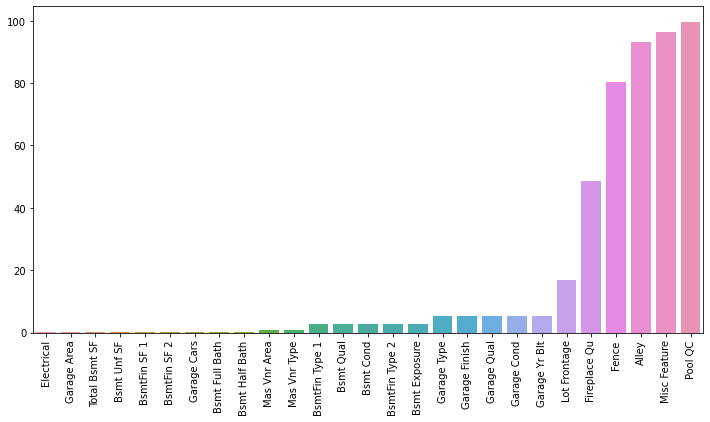

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

(0.0, 1.0)

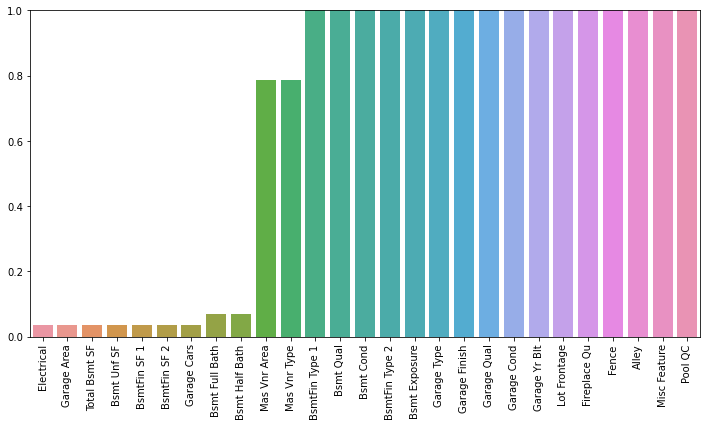

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

In [32]:
nan_percent[nan_percent<1]

Electrical        0.034200
Garage Area       0.034200
Total Bsmt SF     0.034200
Bsmt Unf SF       0.034200
BsmtFin SF 1      0.034200
BsmtFin SF 2      0.034200
Garage Cars       0.034200
Bsmt Full Bath    0.068399
Bsmt Half Bath    0.068399
Mas Vnr Area      0.786594
Mas Vnr Type      0.786594
dtype: float64

In [33]:
nan_percent[nan_percent<1].index

Index(['Electrical', 'Garage Area', 'Total Bsmt SF', 'Bsmt Unf SF',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Garage Cars', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Mas Vnr Area', 'Mas Vnr Type'],
      dtype='object')

In [34]:
100/len(df)

0.03419972640218878

In [35]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [36]:
df[df['Electrical'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1577,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [37]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [38]:
df[df['Garage Area'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2236,70,RM,50.0,9060,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2007,WD,Alloca,150909


In [39]:
df[df['Total Bsmt SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [40]:
index_drop  = df[df['Electrical'].isnull()].index

In [41]:
index_drop

Int64Index([1577], dtype='int64')

In [42]:
df = df.drop(index_drop, axis=0)

In [43]:
index_drop  = df[df['Electrical'].isnull()].index
df = df.drop(index_drop, axis=0)

In [44]:
index_drop  = df[df['Garage Area'].isnull()].index
df = df.drop(index_drop, axis=0)

In [45]:
index_drop  = df[df['Bsmt Unf SF'].isnull()].index
df = df.drop(index_drop, axis=0)

In [46]:
index_drop  = df[df['BsmtFin SF 1'].isnull()].index
df = df.drop(index_drop, axis=0)

In [47]:
index_drop  = df[df['BsmtFin SF 2'].isnull()].index
df = df.drop(index_drop, axis=0)

In [48]:
index_drop  = df[df['Garage Cars'].isnull()].index
df = df.drop(index_drop, axis=0)

In [49]:
index_drop  = df[df['Bsmt Full Bath'].isnull()].index
df = df.drop(index_drop, axis=0)

In [50]:
index_drop  = df[df['Bsmt Half Bath'].isnull()].index
df = df.drop(index_drop, axis=0)

In [51]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [52]:
nan_percent = missing_precent(df)

In [53]:
nan_percent

Mas Vnr Type       0.787671
Mas Vnr Area       0.787671
Bsmt Qual          2.671233
Bsmt Cond          2.671233
BsmtFin Type 1     2.671233
BsmtFin Type 2     2.705479
Bsmt Exposure      2.773973
Garage Type        5.376712
Garage Cond        5.410959
Garage Qual        5.410959
Garage Finish      5.410959
Garage Yr Blt      5.410959
Lot Frontage      16.746575
Fireplace Qu      48.595890
Fence             80.513699
Alley             93.219178
Misc Feature      96.404110
Pool QC           99.623288
dtype: float64

(0.0, 1.0)

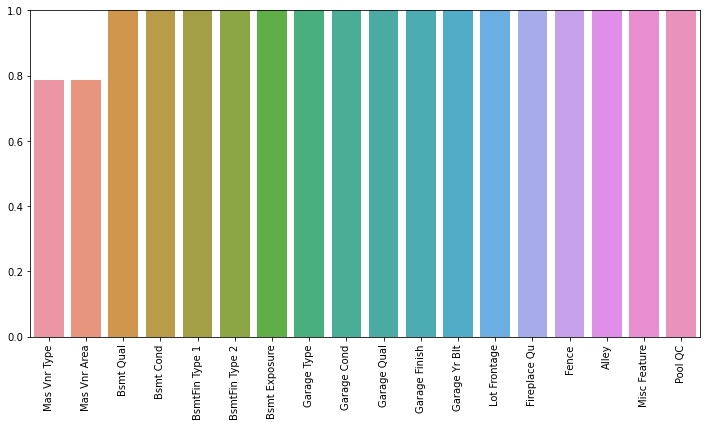

In [54]:
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)
plt.ylim(0, 1)

In [55]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna("None")
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 [Text(0, 0, 'Bsmt Qual'),
  Text(1, 0, 'Bsmt Cond'),
  Text(2, 0, 'BsmtFin Type 1'),
  Text(3, 0, 'BsmtFin Type 2'),
  Text(4, 0, 'Bsmt Exposure'),
  Text(5, 0, 'Garage Type'),
  Text(6, 0, 'Garage Yr Blt'),
  Text(7, 0, 'Garage Finish'),
  Text(8, 0, 'Garage Qual'),
  Text(9, 0, 'Garage Cond'),
  Text(10, 0, 'Lot Frontage'),
  Text(11, 0, 'Fireplace Qu'),
  Text(12, 0, 'Fence'),
  Text(13, 0, 'Alley'),
  Text(14, 0, 'Misc Feature'),
  Text(15, 0, 'Pool QC')])

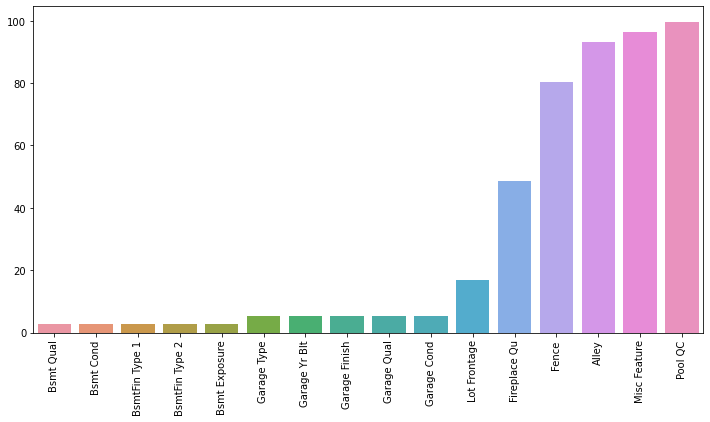

In [56]:
nan_percent=missing_precent(df)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [57]:
df[[ 'Garage Type',
  'Garage Yr Blt',
  'Garage Finish',
  'Garage Qual',
  'Garage Cond']]

,Garage Type,Garage Yr Blt,Garage Finish,Garage Qual,Garage Cond
0,Attchd,1960.0,Fin,TA,TA
1,Attchd,1961.0,Unf,TA,TA
2,Attchd,1958.0,Unf,TA,TA
3,Attchd,1968.0,Fin,TA,TA
4,Attchd,1997.0,Fin,TA,TA
...,...,...,...,...,...
2925,Detchd,1984.0,Unf,TA,TA
2926,Attchd,1983.0,Unf,TA,TA
2927,NaN,NaN,NaN,NaN,NaN
2928,Attchd,1975.0,RFn,TA,TA


In [58]:
df = df.drop(2927, axis=0)

In [59]:
Gar_cols = [ 'Garage Type',
  'Garage Finish',
  'Garage Qual',
  'Garage Cond']

df['Garage Yr Blt']=df['Garage Yr Blt'].fillna('0')
df[Gar_cols] = df[Gar_cols].fillna('None')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 [Text(0, 0, 'Bsmt Qual'),
  Text(1, 0, 'Bsmt Cond'),
  Text(2, 0, 'BsmtFin Type 1'),
  Text(3, 0, 'BsmtFin Type 2'),
  Text(4, 0, 'Bsmt Exposure'),
  Text(5, 0, 'Lot Frontage'),
  Text(6, 0, 'Fireplace Qu'),
  Text(7, 0, 'Fence'),
  Text(8, 0, 'Alley'),
  Text(9, 0, 'Misc Feature'),
  Text(10, 0, 'Pool QC')])

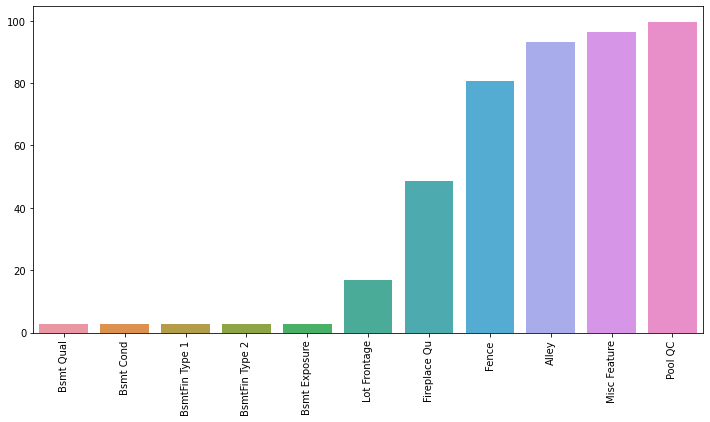

In [60]:
nan_percent=missing_precent(df)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [61]:
bsm_cols = df[['Bsmt Qual',
'Bsmt Cond',
'BsmtFin Type 1',
'BsmtFin Type 2',
'Bsmt Exposure']]

df[['Bsmt Qual',
'Bsmt Cond',
'BsmtFin Type 1',
'BsmtFin Type 2',
'Bsmt Exposure']]= df[['Bsmt Qual',
'Bsmt Cond',
'BsmtFin Type 1',
'BsmtFin Type 2',
'Bsmt Exposure']].fillna('None')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Lot Frontage'),
  Text(1, 0, 'Fireplace Qu'),
  Text(2, 0, 'Fence'),
  Text(3, 0, 'Alley'),
  Text(4, 0, 'Misc Feature'),
  Text(5, 0, 'Pool QC')])

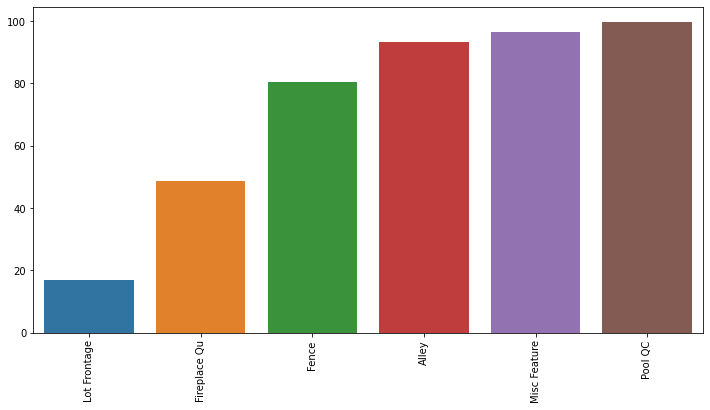

In [62]:
nan_percent=missing_precent(df)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [63]:
df = df.drop(['Fence','Alley','Misc Feature','Pool QC'],axis=1)

(array([0, 1]), [Text(0, 0, 'Lot Frontage'), Text(1, 0, 'Fireplace Qu')])

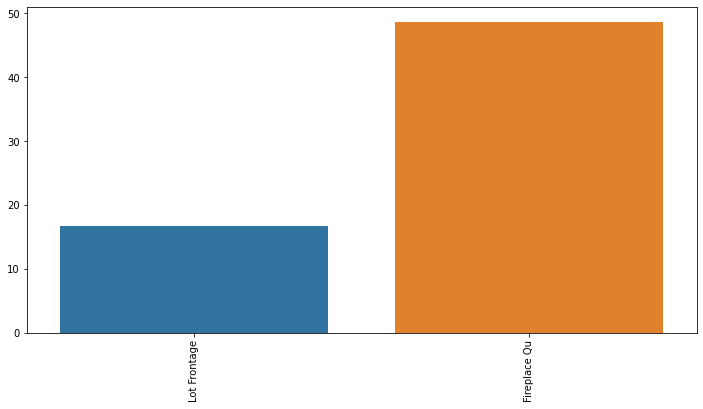

In [64]:
nan_percent=missing_precent(df)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [65]:
df[['Lot Frontage', 'Fireplace Qu']]

,Lot Frontage,Fireplace Qu
0,141.0,Gd
1,80.0,NaN
2,81.0,NaN
3,93.0,TA
4,74.0,TA
...,...,...
2924,160.0,TA
2925,37.0,NaN
2926,NaN,NaN
2928,77.0,TA


In [66]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

In [67]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [68]:
df.corr()['Lot Frontage'].sort_values()

MS SubClass       -0.431700
Overall Cond      -0.074752
Bsmt Half Bath    -0.030213
Yr Sold           -0.006501
Low Qual Fin SF    0.006470
Kitchen AbvGr      0.007714
2nd Flr SF         0.013822
Misc Val           0.014725
Mo Sold            0.017535
Enclosed Porch     0.018003
3Ssn Porch         0.030449
Half Bath          0.030626
BsmtFin SF 2       0.050172
Screen Porch       0.081957
Year Remod/Add     0.086804
Bsmt Full Bath     0.095085
Pool Area          0.105183
Wood Deck SF       0.113424
Year Built         0.116316
Bsmt Unf SF        0.121203
Open Porch SF      0.137450
BsmtFin SF 1       0.161141
Full Bath          0.176296
Overall Qual       0.197752
Mas Vnr Area       0.201679
Fireplaces         0.239926
Bedroom AbvGr      0.243584
Garage Cars        0.310834
Total Bsmt SF      0.312593
TotRms AbvGrd      0.337496
Garage Area        0.344494
Gr Liv Area        0.346248
SalePrice          0.360540
1st Flr SF         0.427153
Lot Area           0.466284
Lot Frontage       1

In [69]:
df['Neighborhood'].unique()

array(['NAmes', 'Gilbert', 'StoneBr', 'NWAmes', 'Somerst', 'BrDale',
       'NPkVill', 'NridgHt', 'Blmngtn', 'NoRidge', 'SawyerW', 'Sawyer',
       'Greens', 'BrkSide', 'OldTown', 'IDOTRR', 'ClearCr', 'SWISU',
       'Edwards', 'CollgCr', 'Crawfor', 'Blueste', 'Mitchel', 'Timber',
       'MeadowV', 'Veenker', 'GrnHill', 'Landmrk'], dtype=object)

<AxesSubplot:xlabel='Lot Frontage', ylabel='Neighborhood'>

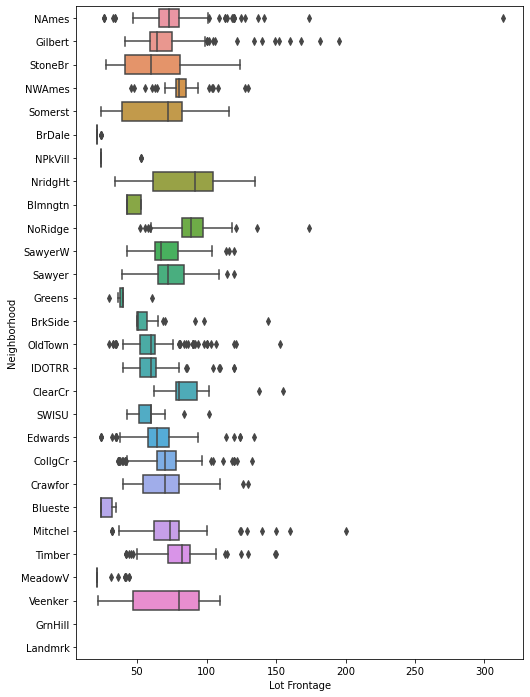

In [70]:
plt.figure(figsize=(8, 12))
sns.boxplot(data=df, x='Lot Frontage', y='Neighborhood')

In [73]:
df.groupby('Neighborhood')['Lot Frontage'].mean()

Neighborhood
Blmngtn    46.900000
Blueste    27.300000
BrDale     21.500000
BrkSide    55.329787
ClearCr    88.150000
CollgCr    71.336364
Crawfor    69.951807
Edwards    64.459770
Gilbert    74.207207
Greens     41.000000
GrnHill          NaN
IDOTRR     62.383721
Landmrk          NaN
MeadowV    25.606061
Mitchel    75.292135
NAmes      75.210667
NPkVill    28.142857
NWAmes     81.517647
NoRidge    90.076923
NridgHt    84.184049
OldTown    61.777293
SWISU      59.068182
Sawyer     74.551020
SawyerW    70.669811
Somerst    64.549383
StoneBr    62.173913
Timber     81.303571
Veenker    72.000000
Name: Lot Frontage, dtype: float64

In [74]:
df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean()))

0       141.000000
1        80.000000
2        81.000000
3        93.000000
4        74.000000
           ...    
2924    160.000000
2925     37.000000
2926     75.292135
2928     77.000000
2929     74.000000
Name: Lot Frontage, Length: 2919, dtype: float64

In [77]:
df['Lot Frontage']=df.groupby('Neighborhood')['Lot Frontage'].transform(lambda val: val.fillna(val.mean()))

(array([0]), [Text(0, 0, 'Lot Frontage')])

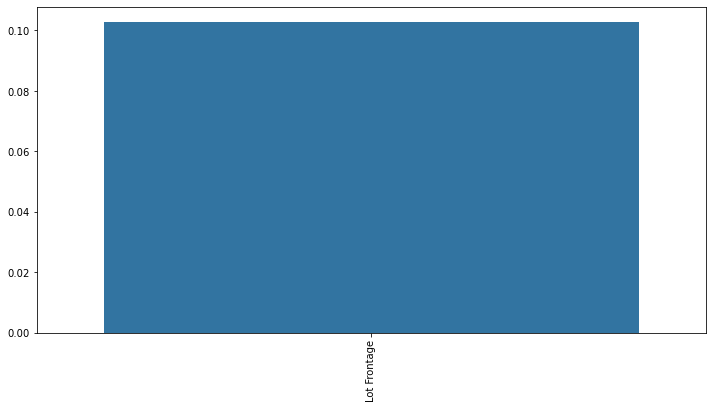

In [78]:
nan_percent=missing_precent(df)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

In [79]:
df['Lot Frontage']=df['Lot Frontage'].fillna(0)


In [81]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,Corner,Gtl,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,3,2010,WD,Normal,189900


In [82]:
nan_percent=missing_precent(df)
print(nan_percent)
plt.figure(figsize=(12, 6))
sns.barplot(x=nan_percent.index, y=nan_percent)
plt.xticks(rotation=90)

Series([], dtype: float64)


ValueError: min() arg is an empty sequence

<Figure size 864x432 with 0 Axes>